# Notebook 5 — Eksperimen Peningkatan Baseline (182 fitur, 49.755 board)

**Tujuan:** Mencoba mengatasi/meningkatkan baseline saat ini — **LightGBM +
`class_weight="balanced"`: 56.4% accuracy, F1 macro 0.410, F1 weighted 0.557**
(test set, lihat `notebooks/04_evaluation.ipynb`) — di atas dataset gabungan
LIN+PBN terbaru (49.755 board, 182 fitur: 164 kanonik + 18 DDS).

**Kenapa ada ruang untuk perbaikan sekarang**: `experiments/2026-07-15/08_baseline_dds_default.ipynb`
menemukan bahwa hyperparameter XGBoost "acc-tuned" yang selama ini dipakai
di `notebooks/03_modeling.ipynb` di-tuning di dataset 10.223 board (2026-07-15),
**bukan** di dataset 49.755 board saat ini (+387% lebih besar). Hasilnya:
XGBoost DEFAULT (57.4% acc, 0.390 F1 macro) sekarang justru MENGALAHKAN
XGBoost "acc-tuned" (56.1% acc, 0.342 F1 macro) di semua metrik.

**Rencana eksperimen** (val set untuk iterasi, test set disentuh sekali di
akhir untuk SELURUH shortlist kandidat final — aturan main yang sama seperti
`experiments/`):

1. **Eksperimen A** — Retuning XGBoost lewat grid manual kecil.
2. **Eksperimen B** — Kandidat terbaik dari A + `sample_weight` seimbang kelas penuh.
3. **Eksperimen C** — Retuning ringan LightGBM lewat grid manual serupa.
4. **Eksperimen D** — Soft-voting ensemble (bobot sama) XGBoost + LightGBM.
5. **Eksperimen E** *(baru)* — Retuning RandomForest lewat grid manual (belum
   pernah dicoba di 182 fitur/49.755 board — RF baseline resmi masih pakai
   hyperparameter `config.yaml` apa adanya).
6. **Eksperimen F** *(baru)* — XGBoost dengan `sample_weight` **parsial**
   (blend antara tanpa bobot dan seimbang penuh) — Eksperimen B menunjukkan
   bobot PENUH terlalu mahal (accuracy -5pp); dicoba titik tengah untuk cari
   trade-off yang lebih baik.
7. **Eksperimen G** *(baru)* — Soft-voting ensemble dengan bobot **dicari**
   (bukan 50/50 tetap seperti Eksperimen D).
8. **Eksperimen H** *(baru)* — Stacking ensemble: meta-learner
   (`LogisticRegression`) di atas `predict_proba` RandomForest + XGBoost +
   LightGBM — metode ensembling yang secara kualitatif berbeda dari
   soft-voting (belajar bobot per-kelas, bukan cuma rata-rata tetap).

> **Catatan keandalan (2026-07-17)**: percobaan awal notebook ini memakai
> `RandomizedSearchCV` dan gagal 3x berturut-turut (timeout 90 menit, lalu
> 40 menit, lalu 60 menit) — ternyata `n_jobs=-1` bersarang (di
> `RandomizedSearchCV` DAN di estimator XGBoost/LightGBM sekaligus)
> menyebabkan multiprocessing/loky di mesin ini jadi jauh lebih lambat
> dari seharusnya, bukan error yang gagal cepat. Ini konsisten dengan
> masalah serupa yang sudah pernah tercatat untuk komputasi DDS (lihat
> `CLAUDE.md`). Semua eksperimen di notebook ini (termasuk yang baru)
> memakai grid manual kecil — satu fit sekuensial per kandidat, `n_jobs=-1`
> HANYA di level estimator, tidak pernah ada CV/multiprocessing bersarang.

**Output yang dihasilkan:**
- `outputs/results/nb05_*.png`, `outputs/results/nb05_summary.json`,
  `outputs/results/nb05_test_comparison.csv`
- **Semua** kandidat pemenang tiap eksperimen disimpan ke `outputs/models/`
  dengan nama deskriptif (`*_expE_*.pkl`, dst.) — **tidak menimpa**
  `outputs/models/xgboost.pkl` / `lightgbm.pkl` yang dipakai
  `03_modeling.ipynb`/`04_evaluation.ipynb`. Disimpan TANPA SYARAT (bukan
  cuma kalau menang dari baseline) supaya bisa dimuat ulang di
  `notebooks/06_final_evaluation.ipynb` untuk perbandingan komprehensif.
  Promosi ke pipeline resmi (`03_modeling.ipynb`) tetap keputusan terpisah,
  lihat kesimpulan di akhir notebook.

**Tahap penelitian:** Tahap 7 (Eksperimen Peningkatan)

> **Prasyarat:** `data/processed/` dan `outputs/models/{xgboost,lightgbm}.pkl`
> harus sudah ada (dari `01_data_extraction.ipynb` dan `03_modeling.ipynb`).


---
## 0. Setup

In [1]:
import sys
import json
import time
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

OUT       = ROOT / 'outputs' / 'results'
MODEL_DIR = ROOT / 'outputs' / 'models'
OUT.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')
print('Setup selesai.')


Setup selesai.


---
## 1. Load Dataset & Baseline Resmi

In [2]:
from src.preprocessing import load_splits
from src.evaluation import evaluate, print_summary

df_train, df_val, df_test, feature_cols, le = load_splits(ROOT / 'data' / 'processed')

X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train['label'].values
X_val   = df_val[feature_cols].values.astype(np.float32)
y_val   = df_val['label'].values
X_test  = df_test[feature_cols].values.astype(np.float32)
y_test  = df_test['label'].values

n_classes  = len(le.classes_)
n_features = len(feature_cols)

print(f'Train  : {X_train.shape}')
print(f'Val    : {X_val.shape}')
print(f'Test   : {X_test.shape}')
print(f'Kelas  : {n_classes}')
print(f'Fitur  : {n_features}  (164 kanonik + 18 DDS)')


Train  : (34832, 182)
Val    : (7462, 182)
Test   : (7461, 182)
Kelas  : 36
Fitur  : 182  (164 kanonik + 18 DDS)


In [3]:
# Muat model resmi (baseline saat ini) untuk jadi titik pembanding
with open(MODEL_DIR / 'xgboost.pkl', 'rb') as f:
    xgb_baseline = pickle.load(f)
with open(MODEL_DIR / 'lightgbm.pkl', 'rb') as f:
    lgbm_baseline = pickle.load(f)
with open(MODEL_DIR / 'randomforest.pkl', 'rb') as f:
    rf_baseline = pickle.load(f)

baseline_results = {}
for m in [rf_baseline, xgb_baseline, lgbm_baseline]:
    y_pred  = m.predict(X_val)
    y_proba = m.predict_proba(X_val)
    res = evaluate(y_val, y_pred, y_proba, le, model_name=m.name)
    baseline_results[m.name] = res
    print_summary(res)



  RandomForest
  Accuracy          : 0.4548
  Precision (macro) : 0.3149
  Recall (macro)    : 0.3614
  F1 (macro)        : 0.3242
  F1 (weighted)     : 0.4728
  Top-3 Accuracy    : 0.7647
  Top-5 Accuracy    : 0.8675



  XGBoost
  Accuracy          : 0.5436
  Precision (macro) : 0.4311
  Recall (macro)    : 0.2986
  F1 (macro)        : 0.3223
  F1 (weighted)     : 0.5127
  Top-3 Accuracy    : 0.8118
  Top-5 Accuracy    : 0.8980



  LightGBM
  Accuracy          : 0.5528
  Precision (macro) : 0.4380
  Recall (macro)    : 0.3709
  F1 (macro)        : 0.3888
  F1 (weighted)     : 0.5434
  Top-3 Accuracy    : 0.8171
  Top-5 Accuracy    : 0.8943


---
## 2. Eksperimen A — Retuning XGBoost di skala 49.755 board

Grid manual kecil (bukan `RandomizedSearchCV`, lihat catatan keandalan di atas), satu fit per kandidat, dipilih berdasar accuracy val set. Ruang yang dicoba jauh lebih longgar dari tuning 2026-07-15 (yang divalidasi di 10.223 board, sekarang terbukti usang — lihat `experiments/2026-07-15/08_baseline_dds_default.ipynb`): pohon lebih dalam, subsample/colsample lebih leluasa, regularisasi lebih ringan, karena dataset ~5x lebih besar punya jauh lebih sedikit risiko overfit di kapasitas yang sama.

In [4]:
from xgboost import XGBClassifier

xgb_param_grid = {
    'default (config.yaml)': dict(n_estimators=300, max_depth=6, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8),
    'deeper_more_trees':     dict(n_estimators=500, max_depth=8, learning_rate=0.05,
                                   subsample=0.9, colsample_bytree=0.8,
                                   min_child_weight=1, reg_lambda=1.0),
    'mid_capacity':          dict(n_estimators=400, max_depth=7, learning_rate=0.08,
                                   subsample=0.85, colsample_bytree=0.7,
                                   min_child_weight=3, reg_lambda=1.5),
    'leaner_faster':         dict(n_estimators=250, max_depth=6, learning_rate=0.1,
                                   subsample=0.8, colsample_bytree=0.8),
}

xgb_grid_results = {}
for cand_name, params in xgb_param_grid.items():
    t0 = time.time()
    clf = XGBClassifier(**params, random_state=42, n_jobs=-1, verbosity=0, eval_metric='mlogloss')
    clf.fit(X_train, y_train)
    elapsed = time.time() - t0
    y_pred  = clf.predict(X_val)
    y_proba = clf.predict_proba(X_val)
    res = evaluate(y_val, y_pred, y_proba, le, model_name=f'XGBoost ({cand_name})')
    xgb_grid_results[cand_name] = {'clf': clf, 'params': params, 'res': res, 'elapsed': elapsed}
    print(f'[{cand_name:<22}] {elapsed:>6.0f}s  acc={res["accuracy"]:.4f}  f1_macro={res["f1_macro"]:.4f}')

best_xgb_name   = max(xgb_grid_results, key=lambda k: xgb_grid_results[k]['res']['accuracy'])
best_xgb_params = xgb_grid_results[best_xgb_name]['params']
print(f'\nKandidat terbaik (accuracy val): {best_xgb_name} -> {best_xgb_params}')


[default (config.yaml) ]    514s  acc=0.5657  f1_macro=0.3872


[deeper_more_trees     ]    369s  acc=0.5596  f1_macro=0.3786


[mid_capacity          ]    558s  acc=0.5578  f1_macro=0.3742


[leaner_faster         ]    179s  acc=0.5637  f1_macro=0.3850

Kandidat terbaik (accuracy val): default (config.yaml) -> {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}


In [5]:
xgb_a = xgb_grid_results[best_xgb_name]['clf']
res_a = xgb_grid_results[best_xgb_name]['res']
res_a['model'] = 'XGBoost (Exp A: retuned)'
y_proba_a = xgb_a.predict_proba(X_val)
print_summary(res_a)

print(f'\nDibanding baseline XGBoost acc-tuned (lama, 10.223-board tuning):')
print(f'  Accuracy : {baseline_results["XGBoost"]["accuracy"]:.4f} -> {res_a["accuracy"]:.4f}'
      f'  ({(res_a["accuracy"]-baseline_results["XGBoost"]["accuracy"])*100:+.2f}pp)')
print(f'  F1 Macro : {baseline_results["XGBoost"]["f1_macro"]:.4f} -> {res_a["f1_macro"]:.4f}'
      f'  ({(res_a["f1_macro"]-baseline_results["XGBoost"]["f1_macro"])*100:+.2f}pp)')



  XGBoost (Exp A: retuned)
  Accuracy          : 0.5657
  Precision (macro) : 0.4696
  Recall (macro)    : 0.3542
  F1 (macro)        : 0.3872
  F1 (weighted)     : 0.5431
  Top-3 Accuracy    : 0.8204
  Top-5 Accuracy    : 0.9026

Dibanding baseline XGBoost acc-tuned (lama, 10.223-board tuning):
  Accuracy : 0.5436 -> 0.5657  (+2.21pp)
  F1 Macro : 0.3223 -> 0.3872  (+6.48pp)


---
## 3. Eksperimen B — XGBoost (params Eksperimen A) + sample_weight seimbang kelas PENUH

XGBoost tidak punya `class_weight="balanced"` native seperti sklearn/LightGBM. Padanannya: `sample_weight` per baris dihitung dari `compute_sample_weight('balanced', y_train)`. Tujuannya menggabungkan accuracy tinggi dari Eksperimen A dengan F1 macro yang lebih baik (seperti keunggulan LightGBM+class_weight atas XGBoost polos).

In [6]:
from sklearn.utils.class_weight import compute_sample_weight

sw_balanced = compute_sample_weight('balanced', y_train)

xgb_b = XGBClassifier(
    **best_xgb_params, random_state=42, n_jobs=-1, verbosity=0, eval_metric='mlogloss',
)
xgb_b.fit(X_train, y_train, sample_weight=sw_balanced)

y_pred_b  = xgb_b.predict(X_val)
y_proba_b = xgb_b.predict_proba(X_val)
res_b = evaluate(y_val, y_pred_b, y_proba_b, le, model_name='XGBoost (Exp B: retuned+balanced)')
print_summary(res_b)

print(f'\nDibanding Eksperimen A (tanpa sample_weight):')
print(f'  Accuracy : {res_a["accuracy"]:.4f} -> {res_b["accuracy"]:.4f}'
      f'  ({(res_b["accuracy"]-res_a["accuracy"])*100:+.2f}pp)')
print(f'  F1 Macro : {res_a["f1_macro"]:.4f} -> {res_b["f1_macro"]:.4f}'
      f'  ({(res_b["f1_macro"]-res_a["f1_macro"])*100:+.2f}pp)')



  XGBoost (Exp B: retuned+balanced)
  Accuracy          : 0.5119
  Precision (macro) : 0.3968
  Recall (macro)    : 0.4335
  F1 (macro)        : 0.4051
  F1 (weighted)     : 0.5285
  Top-3 Accuracy    : 0.7916
  Top-5 Accuracy    : 0.8886

Dibanding Eksperimen A (tanpa sample_weight):
  Accuracy : 0.5657 -> 0.5119  (-5.37pp)
  F1 Macro : 0.3872 -> 0.4051  (+1.79pp)


---
## 4. Eksperimen C — Retuning ringan LightGBM di skala baru

LightGBM+class_weight sudah jadi baseline terbaik proyek, tapi hyperparameter non-class_weight-nya (`num_leaves=63, learning_rate=0.05`, dst.) juga berasal dari `configs/config.yaml` yang tidak pernah di-tuning ulang untuk 182 fitur/49.755 board — cek apakah ada ruang perbaikan tambahan, `class_weight="balanced"` tetap dipertahankan.

In [7]:
from lightgbm import LGBMClassifier

lgbm_param_grid = {
    'default (config.yaml)': dict(n_estimators=300, num_leaves=63, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8),
    'more_leaves':           dict(n_estimators=400, num_leaves=95, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8),
    'lower_lr_more_trees':   dict(n_estimators=500, num_leaves=63, learning_rate=0.03,
                                   subsample=0.85, colsample_bytree=0.7),
    'deep_constrained':      dict(n_estimators=350, num_leaves=127, max_depth=9,
                                   learning_rate=0.05, subsample=0.8, colsample_bytree=0.8),
}

lgbm_grid_results = {}
for cand_name, params in lgbm_param_grid.items():
    t0 = time.time()
    clf = LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1, class_weight='balanced')
    clf.fit(X_train, y_train)
    elapsed = time.time() - t0
    y_pred  = clf.predict(X_val)
    y_proba = clf.predict_proba(X_val)
    res = evaluate(y_val, y_pred, y_proba, le, model_name=f'LightGBM ({cand_name})')
    lgbm_grid_results[cand_name] = {'clf': clf, 'params': params, 'res': res, 'elapsed': elapsed}
    print(f'[{cand_name:<22}] {elapsed:>6.0f}s  acc={res["accuracy"]:.4f}  f1_macro={res["f1_macro"]:.4f}')

# Dipilih berdasar F1 macro (kekuatan utama LightGBM+class_weight di proyek ini),
# bukan accuracy semata
best_lgbm_name   = max(lgbm_grid_results, key=lambda k: lgbm_grid_results[k]['res']['f1_macro'])
best_lgbm_params = lgbm_grid_results[best_lgbm_name]['params']
print(f'\nKandidat terbaik (F1 macro val): {best_lgbm_name} -> {best_lgbm_params}')


[default (config.yaml) ]    343s  acc=0.5528  f1_macro=0.3888


[more_leaves           ]    434s  acc=0.5544  f1_macro=0.3758


[lower_lr_more_trees   ]    182s  acc=0.5529  f1_macro=0.3881


[deep_constrained      ]    164s  acc=0.5512  f1_macro=0.3918

Kandidat terbaik (F1 macro val): deep_constrained -> {'n_estimators': 350, 'num_leaves': 127, 'max_depth': 9, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}


In [8]:
lgbm_c = lgbm_grid_results[best_lgbm_name]['clf']
res_c = lgbm_grid_results[best_lgbm_name]['res']
res_c['model'] = 'LightGBM (Exp C: retuned+balanced)'
y_proba_c = lgbm_c.predict_proba(X_val)
print_summary(res_c)

print(f'\nDibanding baseline LightGBM class_weight (config.yaml default hyperparameter):')
print(f'  Accuracy : {baseline_results["LightGBM"]["accuracy"]:.4f} -> {res_c["accuracy"]:.4f}'
      f'  ({(res_c["accuracy"]-baseline_results["LightGBM"]["accuracy"])*100:+.2f}pp)')
print(f'  F1 Macro : {baseline_results["LightGBM"]["f1_macro"]:.4f} -> {res_c["f1_macro"]:.4f}'
      f'  ({(res_c["f1_macro"]-baseline_results["LightGBM"]["f1_macro"])*100:+.2f}pp)')



  LightGBM (Exp C: retuned+balanced)
  Accuracy          : 0.5512
  Precision (macro) : 0.4421
  Recall (macro)    : 0.3745
  F1 (macro)        : 0.3918
  F1 (weighted)     : 0.5373
  Top-3 Accuracy    : 0.8153
  Top-5 Accuracy    : 0.8983

Dibanding baseline LightGBM class_weight (config.yaml default hyperparameter):
  Accuracy : 0.5528 -> 0.5512  (-0.16pp)
  F1 Macro : 0.3888 -> 0.3918  (+0.30pp)


---
## 5. Eksperimen D — Soft-Voting Ensemble (bobot sama)

Gabungkan kandidat terbaik XGBoost (accuracy tinggi) dengan kandidat terbaik LightGBM (F1 macro tinggi) lewat rata-rata `predict_proba` (soft voting), bobot sama. Idenya: dua model dengan kekuatan berbeda bisa saling menutupi kelemahan di kelas yang berbeda-beda.

In [9]:
# Pilih kandidat XGBoost terbaik (accuracy) dan LightGBM (F1 macro sudah pasti Exp C)
xgb_candidates = {'Exp A': (res_a, y_proba_a), 'Exp B': (res_b, y_proba_b)}
best_xgb_key = max(xgb_candidates, key=lambda k: xgb_candidates[k][0]['accuracy'])
best_xgb_res, best_xgb_proba = xgb_candidates[best_xgb_key]
print(f'XGBoost terbaik (val accuracy): {best_xgb_key} ({best_xgb_res["accuracy"]:.4f})')

ensemble_proba = (best_xgb_proba + y_proba_c) / 2
y_pred_ens = np.argmax(ensemble_proba, axis=1)
res_ens = evaluate(y_val, y_pred_ens, ensemble_proba, le, model_name='Ensemble D (XGBoost+LightGBM, 50/50)')
print_summary(res_ens)


XGBoost terbaik (val accuracy): Exp A (0.5657)

  Ensemble D (XGBoost+LightGBM, 50/50)
  Accuracy          : 0.5610
  Precision (macro) : 0.4490
  Recall (macro)    : 0.3737
  F1 (macro)        : 0.3931
  F1 (weighted)     : 0.5439
  Top-3 Accuracy    : 0.8239
  Top-5 Accuracy    : 0.9049


---
## 6. Eksperimen E — Retuning RandomForest *(baru)*

RandomForest belum pernah di-retuning eksplisit di 182 fitur/49.755 board — baseline resmi masih memakai hyperparameter `config.yaml` apa adanya. RF jauh lebih murah dihitung dari XGBoost/LightGBM (~14 detik per fit di `notebooks/03_modeling.ipynb`), jadi grid di sini bisa lebih leluasa tanpa biaya waktu berarti.

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    'default (config.yaml)': dict(n_estimators=300, max_depth=None, min_samples_split=5),
    'more_trees':            dict(n_estimators=600, max_depth=None, min_samples_split=5),
    'regularized_shallow':   dict(n_estimators=400, max_depth=25, min_samples_split=10,
                                   min_samples_leaf=4),
    'more_features':         dict(n_estimators=400, max_depth=None, min_samples_split=5,
                                   max_features=0.5),
}

rf_grid_results = {}
for cand_name, params in rf_param_grid.items():
    t0 = time.time()
    clf = RandomForestClassifier(**params, class_weight='balanced', random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    elapsed = time.time() - t0
    y_pred  = clf.predict(X_val)
    y_proba = clf.predict_proba(X_val)
    res = evaluate(y_val, y_pred, y_proba, le, model_name=f'RandomForest ({cand_name})')
    rf_grid_results[cand_name] = {'clf': clf, 'params': params, 'res': res, 'elapsed': elapsed}
    print(f'[{cand_name:<22}] {elapsed:>6.0f}s  acc={res["accuracy"]:.4f}  f1_macro={res["f1_macro"]:.4f}')

best_rf_name   = max(rf_grid_results, key=lambda k: rf_grid_results[k]['res']['f1_macro'])
best_rf_params = rf_grid_results[best_rf_name]['params']
print(f'\nKandidat terbaik (F1 macro val): {best_rf_name} -> {best_rf_params}')


[default (config.yaml) ]     21s  acc=0.4548  f1_macro=0.3242


[more_trees            ]     38s  acc=0.4570  f1_macro=0.3319


[regularized_shallow   ]     25s  acc=0.4319  f1_macro=0.3351


[more_features         ]    118s  acc=0.4715  f1_macro=0.3699



Kandidat terbaik (F1 macro val): more_features -> {'n_estimators': 400, 'max_depth': None, 'min_samples_split': 5, 'max_features': 0.5}


In [11]:
rf_e = rf_grid_results[best_rf_name]['clf']
res_e = rf_grid_results[best_rf_name]['res']
res_e['model'] = 'RandomForest (Exp E: retuned)'
y_proba_e = rf_e.predict_proba(X_val)
print_summary(res_e)

print(f'\nDibanding baseline RandomForest (config.yaml):')
print(f'  Accuracy : {baseline_results["RandomForest"]["accuracy"]:.4f} -> {res_e["accuracy"]:.4f}'
      f'  ({(res_e["accuracy"]-baseline_results["RandomForest"]["accuracy"])*100:+.2f}pp)')
print(f'  F1 Macro : {baseline_results["RandomForest"]["f1_macro"]:.4f} -> {res_e["f1_macro"]:.4f}'
      f'  ({(res_e["f1_macro"]-baseline_results["RandomForest"]["f1_macro"])*100:+.2f}pp)')



  RandomForest (Exp E: retuned)
  Accuracy          : 0.4715
  Precision (macro) : 0.3453
  Recall (macro)    : 0.4176
  F1 (macro)        : 0.3699
  F1 (weighted)     : 0.4908
  Top-3 Accuracy    : 0.7556
  Top-5 Accuracy    : 0.8574

Dibanding baseline RandomForest (config.yaml):
  Accuracy : 0.4548 -> 0.4715  (+1.66pp)
  F1 Macro : 0.3242 -> 0.3699  (+4.57pp)


---
## 7. Eksperimen F — XGBoost dengan sample_weight PARSIAL *(baru)*

Eksperimen B (bobot seimbang PENUH) mahal: accuracy -5pp untuk kenaikan F1 macro yang lebih kecil. Di sini dicoba blend parsial antara tanpa bobot (Eksperimen A) dan seimbang penuh (Eksperimen B): `sample_weight = 1 + alpha * (sw_balanced - 1)`, `alpha` di antara 0 (= Eksperimen A) dan 1 (= Eksperimen B), mencari titik tengah yang trade-off-nya lebih baik.

In [12]:
xgb_blend_results = {}
for alpha in [0.25, 0.5, 0.75]:
    sw_blend = 1.0 + alpha * (sw_balanced - 1.0)
    t0 = time.time()
    clf = XGBClassifier(**best_xgb_params, random_state=42, n_jobs=-1, verbosity=0, eval_metric='mlogloss')
    clf.fit(X_train, y_train, sample_weight=sw_blend)
    elapsed = time.time() - t0
    y_pred  = clf.predict(X_val)
    y_proba = clf.predict_proba(X_val)
    res = evaluate(y_val, y_pred, y_proba, le, model_name=f'XGBoost (Exp F: alpha={alpha})')
    xgb_blend_results[alpha] = {'clf': clf, 'res': res, 'elapsed': elapsed}
    print(f'[alpha={alpha:.2f}] {elapsed:>6.0f}s  acc={res["accuracy"]:.4f}  f1_macro={res["f1_macro"]:.4f}')

# Dipilih dengan skor gabungan (rata-rata accuracy & F1 macro) supaya tidak jatuh ke
# salah satu ekstrem seperti Eksperimen A (accuracy-only) atau B (F1-macro-only)
best_alpha = max(xgb_blend_results, key=lambda a: (xgb_blend_results[a]['res']['accuracy'] + xgb_blend_results[a]['res']['f1_macro']) / 2)
print(f'\nAlpha terbaik (skor gabungan acc+F1 macro): {best_alpha}')


[alpha=0.25]    187s  acc=0.5619  f1_macro=0.4020


[alpha=0.50]    171s  acc=0.5496  f1_macro=0.4104


[alpha=0.75]    163s  acc=0.5415  f1_macro=0.4125

Alpha terbaik (skor gabungan acc+F1 macro): 0.25


In [13]:
xgb_f = xgb_blend_results[best_alpha]['clf']
res_f = xgb_blend_results[best_alpha]['res']
res_f['model'] = f'XGBoost (Exp F: soft-balanced alpha={best_alpha})'
y_proba_f = xgb_f.predict_proba(X_val)
print_summary(res_f)

print(f'\nPerbandingan 3 varian bobot kelas XGBoost (val):')
print(f'  {"Varian":<28} {"Accuracy":>9} {"F1 Macro":>9}')
print(f'  {"Exp A (tanpa bobot)":<28} {res_a["accuracy"]:>9.4f} {res_a["f1_macro"]:>9.4f}')
print(f'  {"Exp F (bobot alpha=" + str(best_alpha) + ")":<28} {res_f["accuracy"]:>9.4f} {res_f["f1_macro"]:>9.4f}')
print(f'  {"Exp B (bobot penuh)":<28} {res_b["accuracy"]:>9.4f} {res_b["f1_macro"]:>9.4f}')



  XGBoost (Exp F: soft-balanced alpha=0.25)
  Accuracy          : 0.5619
  Precision (macro) : 0.4477
  Recall (macro)    : 0.3824
  F1 (macro)        : 0.4020
  F1 (weighted)     : 0.5464
  Top-3 Accuracy    : 0.8238
  Top-5 Accuracy    : 0.9028

Perbandingan 3 varian bobot kelas XGBoost (val):
  Varian                        Accuracy  F1 Macro
  Exp A (tanpa bobot)             0.5657    0.3872
  Exp F (bobot alpha=0.25)        0.5619    0.4020
  Exp B (bobot penuh)             0.5119    0.4051


---
## 8. Eksperimen G — Soft-Voting Ensemble dengan bobot dicari *(baru)*

Eksperimen D pakai bobot tetap 50/50. Di sini dicoba grid bobot XGBoost/LightGBM (kelipatan 0.1) tanpa fit ulang sama sekali — cuma kombinasi linear dari `predict_proba` yang sudah dihitung — untuk cari rasio yang lebih baik dari 50/50.

In [14]:
ensemble_weight_results = {}
for w_xgb in [0.3, 0.4, 0.5, 0.6, 0.7]:
    proba_w = w_xgb * best_xgb_proba + (1 - w_xgb) * y_proba_c
    y_pred_w = np.argmax(proba_w, axis=1)
    res_w = evaluate(y_val, y_pred_w, proba_w, le, model_name=f'Ensemble G (w_xgb={w_xgb})')
    ensemble_weight_results[w_xgb] = res_w
    print(f'[w_xgb={w_xgb:.1f}] acc={res_w["accuracy"]:.4f}  f1_macro={res_w["f1_macro"]:.4f}')

best_w_xgb = max(ensemble_weight_results, key=lambda w: ensemble_weight_results[w]['f1_macro'])
res_g = ensemble_weight_results[best_w_xgb]
res_g['model'] = f'Ensemble G (w_xgb={best_w_xgb}, weighted)'
print(f'\nBobot terbaik (F1 macro val): w_xgb={best_w_xgb} -> acc={res_g["accuracy"]:.4f}  f1_macro={res_g["f1_macro"]:.4f}')
print(f'Dibanding Eksperimen D (50/50 tetap): F1 macro {res_ens["f1_macro"]:.4f} -> {res_g["f1_macro"]:.4f}')


[w_xgb=0.3] acc=0.5556  f1_macro=0.3905


[w_xgb=0.4] acc=0.5584  f1_macro=0.3925
[w_xgb=0.5] acc=0.5610  f1_macro=0.3931
[w_xgb=0.6] acc=0.5629  f1_macro=0.3930


[w_xgb=0.7] acc=0.5650  f1_macro=0.3954

Bobot terbaik (F1 macro val): w_xgb=0.7 -> acc=0.5650  f1_macro=0.3954
Dibanding Eksperimen D (50/50 tetap): F1 macro 0.3931 -> 0.3954


---
## 9. Eksperimen H — Stacking Ensemble (meta-learner) *(baru)*

Berbeda secara kualitatif dari soft-voting (Eksperimen D/G, yang cuma rata-rata linear tetap): di sini `LogisticRegression` dilatih di atas `predict_proba` RandomForest + XGBoost + LightGBM sebagai fitur (108 = 36 kelas x 3 model), belajar bobot per-kelas sendiri alih-alih rata-rata seragam. Meta-learner dilatih di val set (base model tidak pernah melihat val selama training) — angka val di bawah bersifat in-sample untuk meta-learner (optimistik), angka TEST di Bagian 10 adalah yang valid karena base model maupun meta-learner sama-sama belum pernah melihat test set.

In [15]:
from sklearn.linear_model import LogisticRegression

stack_base_models = [rf_e, xgb_a, lgbm_c]

def stacking_meta_features(models, X):
    return np.hstack([m.predict_proba(X) for m in models])

X_meta_val = stacking_meta_features(stack_base_models, X_val)

meta_clf = LogisticRegression(max_iter=2000, random_state=42)
meta_clf.fit(X_meta_val, y_val)

y_pred_stack  = meta_clf.predict(X_meta_val)
y_proba_stack = meta_clf.predict_proba(X_meta_val)
res_h = evaluate(y_val, y_pred_stack, y_proba_stack, le, model_name='Stacking H (RF+XGBoost+LightGBM)')
print_summary(res_h)
print('CATATAN: angka val di atas in-sample (meta-learner dilatih & dievaluasi di val yang sama) -- optimistik.')
print('Angka test set (Bagian 10) adalah evaluasi yang valid untuk stacking ini.')



  Stacking H (RF+XGBoost+LightGBM)
  Accuracy          : 0.5826
  Precision (macro) : 0.4979
  Recall (macro)    : 0.3676
  F1 (macro)        : 0.3950
  F1 (weighted)     : 0.5575
  Top-3 Accuracy    : 0.8277
  Top-5 Accuracy    : 0.9020
CATATAN: angka val di atas in-sample (meta-learner dilatih & dievaluasi di val yang sama) -- optimistik.
Angka test set (Bagian 10) adalah evaluasi yang valid untuk stacking ini.


---
## 10. Perbandingan Val Set — Semua Kandidat

In [16]:
from src.evaluation import compare_models

all_val_results = [
    baseline_results['RandomForest'], baseline_results['XGBoost'], baseline_results['LightGBM'],
    res_a, res_b, res_c, res_ens, res_e, res_f, res_g, res_h,
]
val_comparison = compare_models(all_val_results)
print('=== Perbandingan Validation Set — Baseline vs Eksperimen (182 fitur, 49.755 board) ===')
display(val_comparison.style
    .format('{:.4f}')
    .highlight_max(color='#C8E6C9', axis=0)
    .set_caption('Hijau = nilai terbaik per metrik (catatan: skor Stacking H in-sample)'))


=== Perbandingan Validation Set — Baseline vs Eksperimen (182 fitur, 49.755 board) ===


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top_3_accuracy,top_5_accuracy
model,,,,,,,
RandomForest,0.4548,0.3149,0.3614,0.3242,0.4728,0.7647,0.8675
XGBoost,0.5436,0.4311,0.2986,0.3223,0.5127,0.8118,0.8980
LightGBM,0.5528,0.4380,0.3709,0.3888,0.5434,0.8171,0.8943
XGBoost (Exp A: retuned),0.5657,0.4696,0.3542,0.3872,0.5431,0.8204,0.9026
XGBoost (Exp B: retuned+balanced),0.5119,0.3968,0.4335,0.4051,0.5285,0.7916,0.8886
LightGBM (Exp C: retuned+balanced),0.5512,0.4421,0.3745,0.3918,0.5373,0.8153,0.8983
"Ensemble D (XGBoost+LightGBM, 50/50)",0.5610,0.4490,0.3737,0.3931,0.5439,0.8239,0.9049
RandomForest (Exp E: retuned),0.4715,0.3453,0.4176,0.3699,0.4908,0.7556,0.8574
XGBoost (Exp F: soft-balanced alpha=0.25),0.5619,0.4477,0.3824,0.4020,0.5464,0.8238,0.9028


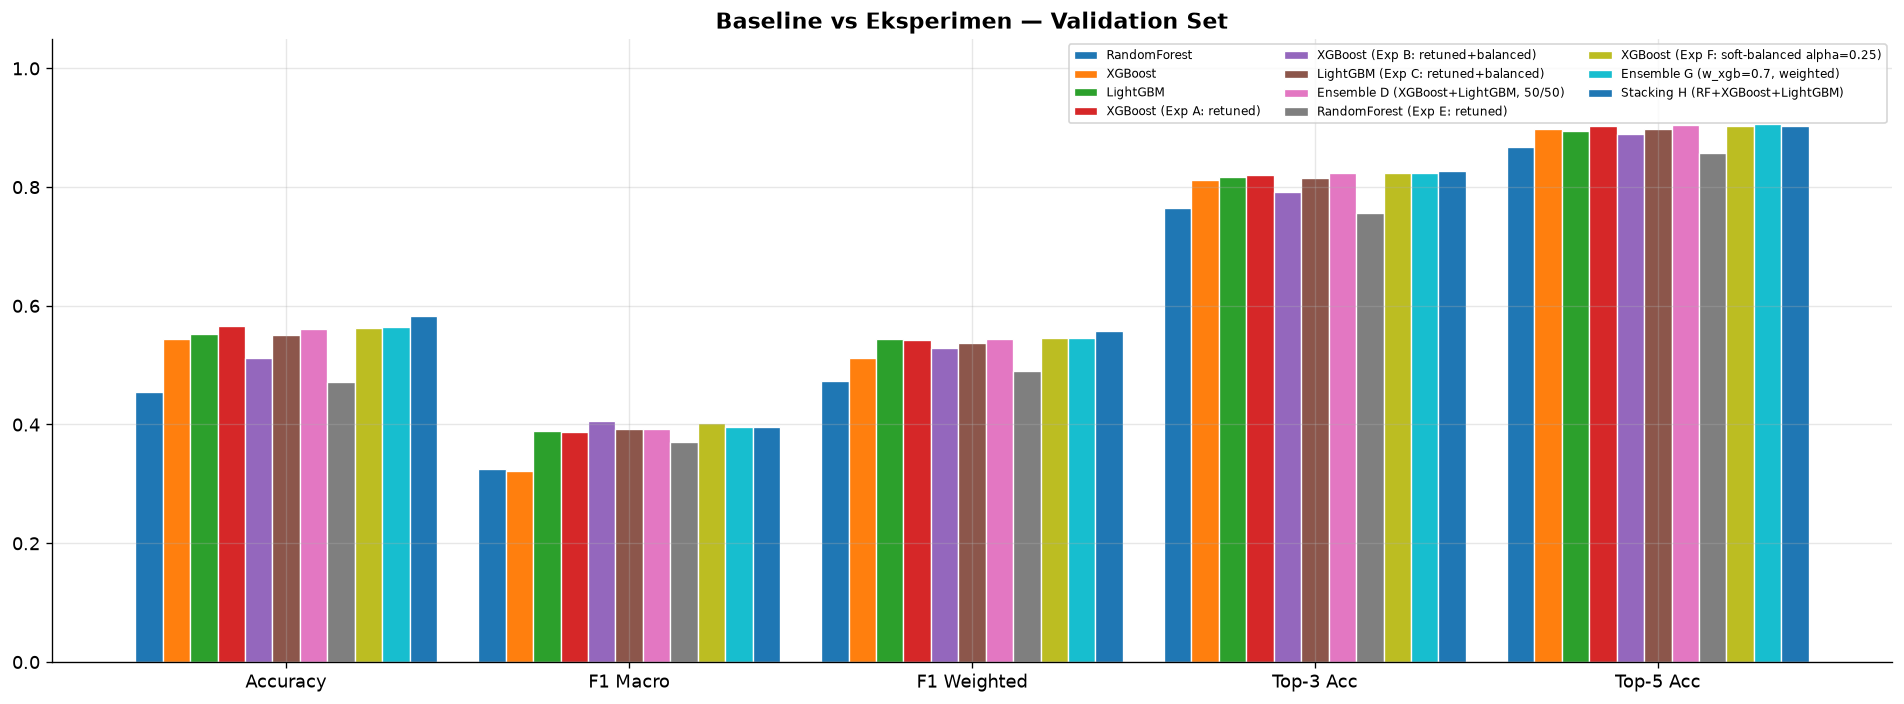

In [17]:
fig, ax = plt.subplots(figsize=(16, 6))
metrics_plot  = ['accuracy', 'f1_macro', 'f1_weighted', 'top_3_accuracy', 'top_5_accuracy']
metrics_label = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Top-3 Acc', 'Top-5 Acc']
x = np.arange(len(metrics_plot))
w = 0.08
colors_all = sns.color_palette('tab10', len(all_val_results))

for i, (res, color) in enumerate(zip(all_val_results, colors_all)):
    vals = [res.get(m, 0) for m in metrics_plot]
    ax.bar(x + i * w, vals, w, label=res['model'], color=color, edgecolor='white', linewidth=0.8)

ax.set_xticks(x + w * (len(all_val_results) - 1) / 2)
ax.set_xticklabels(metrics_label, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Baseline vs Eksperimen — Validation Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.savefig(OUT / 'nb05_val_comparison.png', bbox_inches='tight')
plt.show()


---
## 11. Evaluasi Final — Test Set (seluruh shortlist, disentuh sekali)

Seluruh kandidat di atas dievaluasi SEKALIGUS di test set — bukan iterasi bertahap berdasar umpan balik test, cuma satu batch akhir untuk shortlist yang sudah diputuskan lewat val set di atas. Tidak ada penyesuaian lebih lanjut setelah ini.

In [18]:
test_final_results = []

# --- Model tunggal (RF/XGBoost/LightGBM) ---
single_candidates = {
    'RandomForest (Exp E: retuned)':        rf_e,
    'XGBoost (Exp A: retuned)':             xgb_a,
    'XGBoost (Exp B: retuned+balanced)':    xgb_b,
    'XGBoost (Exp F: soft-balanced)':       xgb_f,
    'LightGBM (Exp C: retuned+balanced)':   lgbm_c,
}
for name, model in single_candidates.items():
    y_pred_t  = model.predict(X_test)
    y_proba_t = model.predict_proba(X_test)
    res_t = evaluate(y_test, y_pred_t, y_proba_t, le, model_name=name)
    test_final_results.append(res_t)
    print_summary(res_t)



  RandomForest (Exp E: retuned)
  Accuracy          : 0.4885
  Precision (macro) : 0.3694
  Recall (macro)    : 0.4343
  F1 (macro)        : 0.3901
  F1 (weighted)     : 0.5072
  Top-3 Accuracy    : 0.7680
  Top-5 Accuracy    : 0.8666



  XGBoost (Exp A: retuned)
  Accuracy          : 0.5745
  Precision (macro) : 0.4663
  Recall (macro)    : 0.3605
  F1 (macro)        : 0.3901
  F1 (weighted)     : 0.5540
  Top-3 Accuracy    : 0.8263
  Top-5 Accuracy    : 0.9047



  XGBoost (Exp B: retuned+balanced)
  Accuracy          : 0.5243
  Precision (macro) : 0.3961
  Recall (macro)    : 0.4343
  F1 (macro)        : 0.4070
  F1 (weighted)     : 0.5395
  Top-3 Accuracy    : 0.8012
  Top-5 Accuracy    : 0.8963



  XGBoost (Exp F: soft-balanced)
  Accuracy          : 0.5746
  Precision (macro) : 0.4608
  Recall (macro)    : 0.3841
  F1 (macro)        : 0.4064
  F1 (weighted)     : 0.5597
  Top-3 Accuracy    : 0.8272
  Top-5 Accuracy    : 0.9073



  LightGBM (Exp C: retuned+balanced)
  Accuracy          : 0.5558
  Precision (macro) : 0.4392
  Recall (macro)    : 0.3750
  F1 (macro)        : 0.3940
  F1 (weighted)     : 0.5442
  Top-3 Accuracy    : 0.8185
  Top-5 Accuracy    : 0.8965


In [19]:
from src.evaluation import save_results

# --- Ensemble D: XGBoost terbaik (val accuracy) + LightGBM Exp C, bobot 50/50 ---
proba_test_d = (single_candidates['XGBoost (Exp A: retuned)' if best_xgb_key == 'Exp A' else 'XGBoost (Exp B: retuned+balanced)'].predict_proba(X_test) + lgbm_c.predict_proba(X_test)) / 2
y_pred_test_d = np.argmax(proba_test_d, axis=1)
res_ens_test = evaluate(y_test, y_pred_test_d, proba_test_d, le, model_name='Ensemble D (XGBoost+LightGBM, 50/50)')
test_final_results.append(res_ens_test)
print_summary(res_ens_test)

# --- Ensemble G: bobot terbaik hasil pencarian di val set (pakai XGBoost yang sama
# dengan best_xgb_proba yang dipakai saat mencari bobot di Bagian 8) ---
xgb_for_ensemble_g = single_candidates['XGBoost (Exp A: retuned)' if best_xgb_key == 'Exp A' else 'XGBoost (Exp B: retuned+balanced)']
proba_test_g = best_w_xgb * xgb_for_ensemble_g.predict_proba(X_test) + (1 - best_w_xgb) * lgbm_c.predict_proba(X_test)
y_pred_test_g = np.argmax(proba_test_g, axis=1)
res_ens_g_test = evaluate(y_test, y_pred_test_g, proba_test_g, le, model_name=f'Ensemble G (w_xgb={best_w_xgb}, weighted)')
test_final_results.append(res_ens_g_test)
print_summary(res_ens_g_test)

# --- Stacking H: base model + meta-learner, semua dievaluasi di test yang belum pernah dilihat ---
X_meta_test = stacking_meta_features(stack_base_models, X_test)
y_pred_stack_test  = meta_clf.predict(X_meta_test)
y_proba_stack_test = meta_clf.predict_proba(X_meta_test)
res_stack_test = evaluate(y_test, y_pred_stack_test, y_proba_stack_test, le, model_name='Stacking H (RF+XGBoost+LightGBM)')
test_final_results.append(res_stack_test)
print_summary(res_stack_test)

for res_t, fname in [
    (res_ens_test, 'nb05_ensemble_d_test.json'),
    (res_ens_g_test, 'nb05_ensemble_g_test.json'),
    (res_stack_test, 'nb05_stacking_h_test.json'),
]:
    save_results(res_t, OUT / fname)



  Ensemble D (XGBoost+LightGBM, 50/50)
  Accuracy          : 0.5691
  Precision (macro) : 0.4484
  Recall (macro)    : 0.3792
  F1 (macro)        : 0.3997
  F1 (weighted)     : 0.5551
  Top-3 Accuracy    : 0.8271
  Top-5 Accuracy    : 0.9059



  Ensemble G (w_xgb=0.7, weighted)
  Accuracy          : 0.5728
  Precision (macro) : 0.4536
  Recall (macro)    : 0.3739
  F1 (macro)        : 0.3971
  F1 (weighted)     : 0.5562
  Top-3 Accuracy    : 0.8294
  Top-5 Accuracy    : 0.9068



  Stacking H (RF+XGBoost+LightGBM)
  Accuracy          : 0.5817
  Precision (macro) : 0.4612
  Recall (macro)    : 0.3587
  F1 (macro)        : 0.3844
  F1 (weighted)     : 0.5591
  Top-3 Accuracy    : 0.8117
  Top-5 Accuracy    : 0.8841


In [20]:
baseline_test_results = []
for fname, name in [
    ('randomforest.pkl', 'RandomForest (baseline resmi)'),
    ('xgboost.pkl', 'XGBoost (baseline resmi)'),
    ('lightgbm.pkl', 'LightGBM (baseline resmi)'),
]:
    with open(MODEL_DIR / fname, 'rb') as f:
        m = pickle.load(f)
    y_pred_bt  = m.predict(X_test)
    y_proba_bt = m.predict_proba(X_test)
    res_bt = evaluate(y_test, y_pred_bt, y_proba_bt, le, model_name=name)
    baseline_test_results.append(res_bt)

test_comparison_nb05 = compare_models(baseline_test_results + test_final_results)
test_comparison_nb05.to_csv(OUT / 'nb05_test_comparison.csv')

print('=== Perbandingan Test Set — Baseline Resmi vs SELURUH Kandidat Notebook 5 ===')
display(test_comparison_nb05.style
    .format('{:.4f}')
    .highlight_max(color='#C8E6C9', axis=0)
    .highlight_min(color='#FFCDD2', axis=0)
    .set_caption('Hijau = terbaik, Merah = terburuk per metrik'))


=== Perbandingan Test Set — Baseline Resmi vs SELURUH Kandidat Notebook 5 ===


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top_3_accuracy,top_5_accuracy
model,,,,,,,
RandomForest (baseline resmi),0.4684,0.3129,0.3615,0.3251,0.4854,0.7715,0.8737
XGBoost (baseline resmi),0.5611,0.4615,0.3145,0.3416,0.5322,0.8175,0.8984
LightGBM (baseline resmi),0.5639,0.4543,0.3915,0.4101,0.5567,0.8208,0.8972
RandomForest (Exp E: retuned),0.4885,0.3694,0.4343,0.3901,0.5072,0.7680,0.8666
XGBoost (Exp A: retuned),0.5745,0.4663,0.3605,0.3901,0.5540,0.8263,0.9047
XGBoost (Exp B: retuned+balanced),0.5243,0.3961,0.4343,0.4070,0.5395,0.8012,0.8963
XGBoost (Exp F: soft-balanced),0.5746,0.4608,0.3841,0.4064,0.5597,0.8272,0.9073
LightGBM (Exp C: retuned+balanced),0.5558,0.4392,0.3750,0.3940,0.5442,0.8185,0.8965
"Ensemble D (XGBoost+LightGBM, 50/50)",0.5691,0.4484,0.3792,0.3997,0.5551,0.8271,0.9059


---
## 12. Simpan Model Terbaik (2026-07-21: dipangkas jadi 2 model saja)

Semua 8 kandidat awalnya disimpan TANPA SYARAT supaya
`notebooks/06_final_evaluation.ipynb` bisa memuat semuanya untuk laporan
komprehensif satu kali (sudah selesai dijalankan, angkanya sudah terekam
permanen di `CLAUDE.md` dan `outputs/results/nb06_final_comparison.csv`).

Setelah laporan itu selesai, disk dipangkas — hanya **2 model terbaik**
yang benar-benar disimpan ke depannya:
- **`xgboost_expF_softbalance.pkl`** — kandidat "all-around terbaik":
  F1 macro nyaris menyamai LightGBM baseline (0.406 vs 0.410) TAPI unggul
  accuracy, F1 weighted, dan top-3/top-5 dari SEMUA kandidat.
- **`stacking_expH_meta_logreg.pkl`** — accuracy tertinggi dari seluruh
  proyek (58.2%), meta-learner-nya sendiri kecil (~32KB).

**Dihapus** (superseded / tidak lagi kompetitif, termasuk RandomForest Exp
E yang 1.29GB sendirian): `randomforest_expE_retuned.pkl`,
`lightgbm_expC_retuned.pkl` (kalah dari LightGBM baseline resmi di semua
metrik), `xgboost_expA_default.pkl`, `xgboost_expB_balanced.pkl`
(keduanya didominasi Exp F), `ensemble_manifest.json` (bergantung ke file
yang sudah dihapus).

> **Catatan penting**: `stacking_expH_meta_logreg.pkl` kini **beku**
> (frozen) — 3 model dasarnya (RF Exp E, XGBoost Exp A, LightGBM Exp C)
> sudah dihapus, jadi meta-learner ini TIDAK BISA dipakai ulang langsung.
> Lihat `outputs/models/stacking_manifest.json` (field `"status"`) untuk
> cara memulihkannya kalau suatu saat dibutuhkan lagi. Disimpan tetap
> sebagai bukti/dokumentasi hasil (58.2% accuracy), bukan artefak siap
> pakai.


In [ ]:
from src.models import XGBModel

def wrap_and_save(model_cls, params, fitted_clf, filename):
    wrapped = model_cls(**params)
    wrapped.clf = fitted_clf
    wrapped.save(MODEL_DIR / filename)
    print(f'  Disimpan: {filename}')

print('Menyimpan HANYA 2 model terbaik notebook 5 (2026-07-21 -- lihat markdown di atas) ...')
wrap_and_save(XGBModel, best_xgb_params, xgb_f, 'xgboost_expF_softbalance.pkl')

with open(MODEL_DIR / 'stacking_expH_meta_logreg.pkl', 'wb') as f:
    pickle.dump(meta_clf, f)
print('  Disimpan: stacking_expH_meta_logreg.pkl  (FROZEN -- base model dasarnya tidak disimpan lagi, lihat markdown di atas)')

stacking_manifest = {
    'meta_learner': 'stacking_expH_meta_logreg.pkl',
    'base_models_in_order': [
        'randomforest_expE_retuned.pkl',
        'xgboost_expA_default.pkl',
        'lightgbm_expC_retuned.pkl',
    ],
    'note': 'Meta-features = hstack([m.predict_proba(X) for m in base_models_in_order]).',
    'status': (
        'FROZEN (2026-07-21): base_models_in_order files were deleted to reclaim disk '
        'space (randomforest_expE_retuned.pkl alone was 1.29GB) after this model\'s '
        'final test-set result (58.2% accuracy, 0.384 F1 macro) was already recorded in '
        'CLAUDE.md and outputs/results/nb06_final_comparison.csv. This meta-learner pkl '
        'cannot be used standalone anymore -- to reuse or re-evaluate it, re-run this '
        'notebook\'s sections 6 (Exp E), 2 (Exp A), and 4 (Exp C) first to regenerate the '
        '3 base model files with the exact same hyperparameters/random_state, or refit a '
        'fresh stacking model against currently-kept models instead.'
    ),
}
with open(MODEL_DIR / 'stacking_manifest.json', 'w', encoding='utf-8') as f:
    json.dump(stacking_manifest, f, indent=2)
print('  Disimpan: stacking_manifest.json (dengan catatan status FROZEN)')

print()
print('Model DIHAPUS setelah notebooks/06_final_evaluation.ipynb selesai (superseded/tidak kompetitif):')
for fname in ['randomforest_expE_retuned.pkl', 'lightgbm_expC_retuned.pkl',
              'xgboost_expA_default.pkl', 'xgboost_expB_balanced.pkl', 'ensemble_manifest.json']:
    print(f'  - {fname}')


Menyimpan HANYA 2 model terbaik notebook 5 (2026-07-21 -- lihat markdown di atas) ...
  Disimpan: xgboost_expF_softbalance.pkl
  Disimpan: stacking_expH_meta_logreg.pkl  (FROZEN -- base model dasarnya tidak disimpan lagi, lihat markdown di atas)
  Disimpan: stacking_manifest.json (dengan catatan status FROZEN)

Model DIHAPUS setelah notebooks/06_final_evaluation.ipynb selesai (superseded/tidak kompetitif):
  - randomforest_expE_retuned.pkl
  - lightgbm_expC_retuned.pkl
  - xgboost_expA_default.pkl
  - xgboost_expB_balanced.pkl
  - ensemble_manifest.json


---
## Kesimpulan & Rekomendasi Promosi

In [22]:
overall_best_test = max(baseline_test_results + test_final_results, key=lambda r: r['f1_macro'])
best_acc_test     = max(baseline_test_results + test_final_results, key=lambda r: r['accuracy'])

summary_nb05 = {
    'baseline_test': {r['model']: {k: r[k] for k in ['accuracy','f1_macro','f1_weighted','top_3_accuracy','top_5_accuracy']} for r in baseline_test_results},
    'experiment_test': {r['model']: {k: r[k] for k in ['accuracy','f1_macro','f1_weighted','top_3_accuracy','top_5_accuracy']} for r in test_final_results},
    'best_xgb_params_exp_a': best_xgb_params,
    'best_lgbm_params_exp_c': best_lgbm_params,
    'best_rf_params_exp_e': best_rf_params,
    'best_alpha_exp_f': best_alpha,
    'best_w_xgb_exp_g': best_w_xgb,
    'overall_best_model_by_f1_macro': overall_best_test['model'],
    'overall_best_model_by_accuracy': best_acc_test['model'],
}
with open(OUT / 'nb05_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_nb05, f, indent=2, ensure_ascii=False)

print('=' * 70)
print('  RINGKASAN NOTEBOOK 5 — Eksperimen Peningkatan Baseline (A-H)')
print('=' * 70)
print(f'\nBaseline resmi (test set, notebooks/04_evaluation.ipynb):')
for r in baseline_test_results:
    print(f'  {r["model"]:<40}: acc={r["accuracy"]:.4f}  f1_macro={r["f1_macro"]:.4f}  f1_weighted={r["f1_weighted"]:.4f}')
print(f'\nKandidat notebook 5 (test set):')
for r in test_final_results:
    print(f'  {r["model"]:<40}: acc={r["accuracy"]:.4f}  f1_macro={r["f1_macro"]:.4f}  f1_weighted={r["f1_weighted"]:.4f}')
print(f'\nTerbaik keseluruhan (by F1 macro) : {overall_best_test["model"]}  ({overall_best_test["f1_macro"]:.4f})')
print(f'Terbaik keseluruhan (by accuracy) : {best_acc_test["model"]}  ({best_acc_test["accuracy"]:.4f})')
print('=' * 70)
print()
print('Lanjut ke: notebooks/06_final_evaluation.ipynb -> analisis komprehensif')
print('(confusion matrix, feature importance, SHAP, radar chart) atas seluruh shortlist ini.')


  RINGKASAN NOTEBOOK 5 — Eksperimen Peningkatan Baseline (A-H)

Baseline resmi (test set, notebooks/04_evaluation.ipynb):
  RandomForest (baseline resmi)           : acc=0.4684  f1_macro=0.3251  f1_weighted=0.4854
  XGBoost (baseline resmi)                : acc=0.5611  f1_macro=0.3416  f1_weighted=0.5322
  LightGBM (baseline resmi)               : acc=0.5639  f1_macro=0.4101  f1_weighted=0.5567

Kandidat notebook 5 (test set):
  RandomForest (Exp E: retuned)           : acc=0.4885  f1_macro=0.3901  f1_weighted=0.5072
  XGBoost (Exp A: retuned)                : acc=0.5745  f1_macro=0.3901  f1_weighted=0.5540
  XGBoost (Exp B: retuned+balanced)       : acc=0.5243  f1_macro=0.4070  f1_weighted=0.5395
  XGBoost (Exp F: soft-balanced)          : acc=0.5746  f1_macro=0.4064  f1_weighted=0.5597
  LightGBM (Exp C: retuned+balanced)      : acc=0.5558  f1_macro=0.3940  f1_weighted=0.5442
  Ensemble D (XGBoost+LightGBM, 50/50)    : acc=0.5691  f1_macro=0.3997  f1_weighted=0.5551
  Ensemble G (w_x